# EDA

Perform EDA on the data provided. This includes:
- Identifying data quality issues
- Identifying missing values

Outputs from this notebook are saved onto `plots` folder

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Load Datasets

In [19]:
# Get the current directory
current_directory = os.getcwd()
path = os.path.join(current_directory, "datasets")
print(f"Fetching data from directory: {path}")

# ... TICKETMASTER ...
# `ticket_purchases`: Online ticket purchases per event
ticket_purchases_df = pd.read_csv(f"{path}/ticket_purchases.csv")
print(f"... `ticket_purchases.csv` loaded {ticket_purchases_df.shape}")

# `event_attendance`: Attendance scan-ins by customers
event_attendance_df = pd.read_csv(f"{path}/event_attendance.csv")
print(f"... `event_attendance.csv` loaded {event_attendance_df.shape}")

# `events`: Metadata for each event
events_df = pd.read_csv(f"{path}/events.csv")
print(f"... `events.csv` loaded {events_df.shape}")

# ... SALESFORCE CRM ...
# `crm_interactions`: Contact history and opportunity stages
crm_interactions_df = pd.read_csv(f"{path}/crm_interactions.csv")
print(f"... `crm_interactions.csv` loaded {crm_interactions_df.shape}")

# ... GOOGLE ANALYTICS ...
# `web_sessions`: Website sessions including source, duration, and engagement
web_sessions_df = pd.read_csv(f"{path}/web_sessions.csv")
print(f"... `web_sessions.csv` loaded {web_sessions_df.shape}")

# ... RETAIL POS ...
# `retail_transactions`: In-venue or merchandise store purchases
retail_transactions_df = pd.read_csv(f"{path}/retail_transactions.csv")
print(f"... `retail_transactions.csv` loaded {retail_transactions_df.shape}")

# ... CUSTOMER PROFILES ...
# `customers`: Partial demographic and signup metadata across systems
customers_df = pd.read_csv(f"{path}/customers.csv")
print(f"... `customers.csv` loaded {customers_df.shape}")

# ... CUSTOMER LINKAGE ...
# `customer_linkage`: A mapping table linking system-specific customer IDs to a shared universal_id
customer_linkage_df = pd.read_csv(f"{path}/customer_linkage.csv")
print(f"... `customer_linkage.csv` loaded {customer_linkage_df.shape}")

Fetching data from directory: /Users/wildg/Desktop/compass-analytics-interview/datasets
... `ticket_purchases.csv` loaded (500, 4)
... `event_attendance.csv` loaded (600, 3)
... `events.csv` loaded (50, 3)
... `crm_interactions.csv` loaded (400, 4)
... `web_sessions.csv` loaded (1000, 5)
... `retail_transactions.csv` loaded (700, 5)
... `customers.csv` loaded (200, 5)
... `customer_linkage.csv` loaded (120, 5)


## Data Quality Issues

Validate the data quality by checking for duplicates, missing values, and data types

In [20]:
datasets = {
  "crm_interactions": crm_interactions_df,
  "customers": customers_df,
  "event_attendance": event_attendance_df,
  "events": events_df,
  "retail_transactions": retail_transactions_df,
  "ticket_purchases": ticket_purchases_df,
  "web_sessions": web_sessions_df,
  "customer_linkage": customer_linkage_df
}

In [21]:
# Loop through each dataset and print information about each column
for name, df in datasets.items():
  print(f"===== {name} COLUMN INFO =====")
  display(df.info(memory_usage=False))

===== crm_interactions COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        400 non-null    object
 1   contact_date       400 non-null    object
 2   interaction_type   400 non-null    object
 3   opportunity_stage  400 non-null    object
dtypes: object(4)

None

===== customers COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  200 non-null    object
 1   signup_date  200 non-null    object
 2   city         200 non-null    object
 3   gender       200 non-null    object
 4   age_group    200 non-null    object
dtypes: object(5)

None

===== event_attendance COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     600 non-null    object
 1   event_id        600 non-null    object
 2   scan_timestamp  600 non-null    object
dtypes: object(3)

...

None

===== web_sessions COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       1000 non-null   object
 1   session_date      1000 non-null   object
 2   source            1000 non-null   object
 3   page_views        1000 non-null   int64 
 4   duration_seconds  1000 non-null   int64 
dtypes: int64(2), object(3)

None

===== customer_linkage COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   universal_id  120 non-null    object
 1   tmc_id        93 non-null     object
 2   sfc_id        94 non-null     object
 3   gac_id        95 non-null     object
 4   rtc_id        99 non-null     object
dtypes: object(5)

None

In [22]:
# Loop through each dataset and check for duplicates
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name} has {duplicates} duplicate rows.")

crm_interactions has 0 duplicate rows.
customers has 0 duplicate rows.
event_attendance has 0 duplicate rows.
events has 0 duplicate rows.
retail_transactions has 0 duplicate rows.
ticket_purchases has 0 duplicate rows.
web_sessions has 0 duplicate rows.
customer_linkage has 0 duplicate rows.


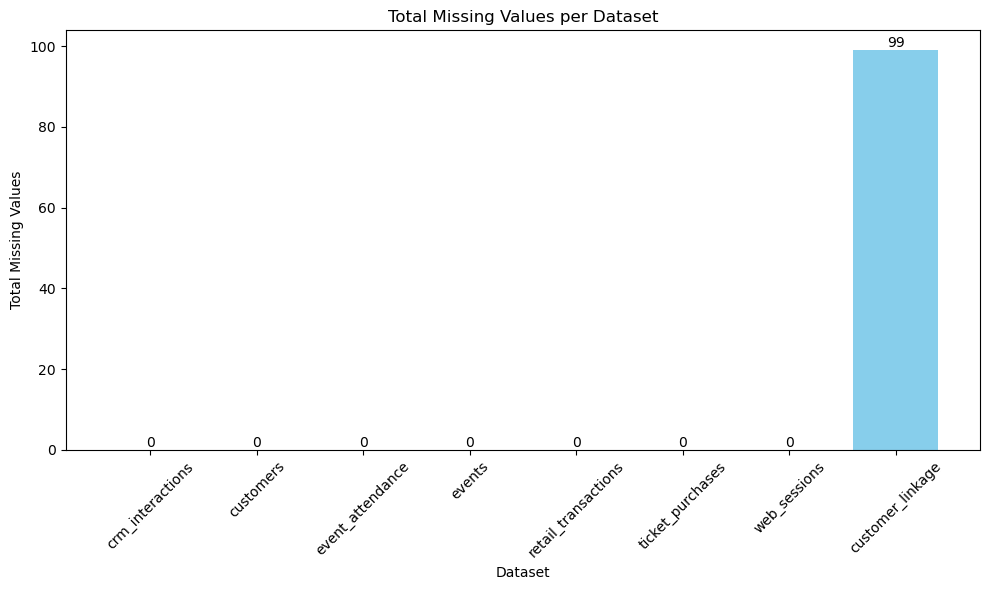

In [23]:
total_missing_data = {}

# Loop through each dataset and count missing values
for name, df in datasets.items():
  total_missing_data[name] = df.isnull().sum().sum()

# Plot the total_missing_data
plt.figure(figsize=(10, 6))
bars = plt.bar(
  total_missing_data.keys(),
  total_missing_data.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.xlabel('Dataset')
plt.ylabel('Total Missing Values')
plt.title('Total Missing Values per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/total_missing_values.png')
plt.show()

In [24]:
# Check for `customer_id`s in `customers_df` that are not present in any other tables
customer_ids = set(customers_df['customer_id'])
used_customer_ids = set()
for name, df in datasets.items():
  if 'customer_id' in df.columns:
    used_customer_ids.update(df['customer_id'].unique())

unmatched_customer_ids = customer_ids - used_customer_ids
print(f"Number of unused customer_ids: {len(unmatched_customer_ids)}")

Number of unused customer_ids: 0


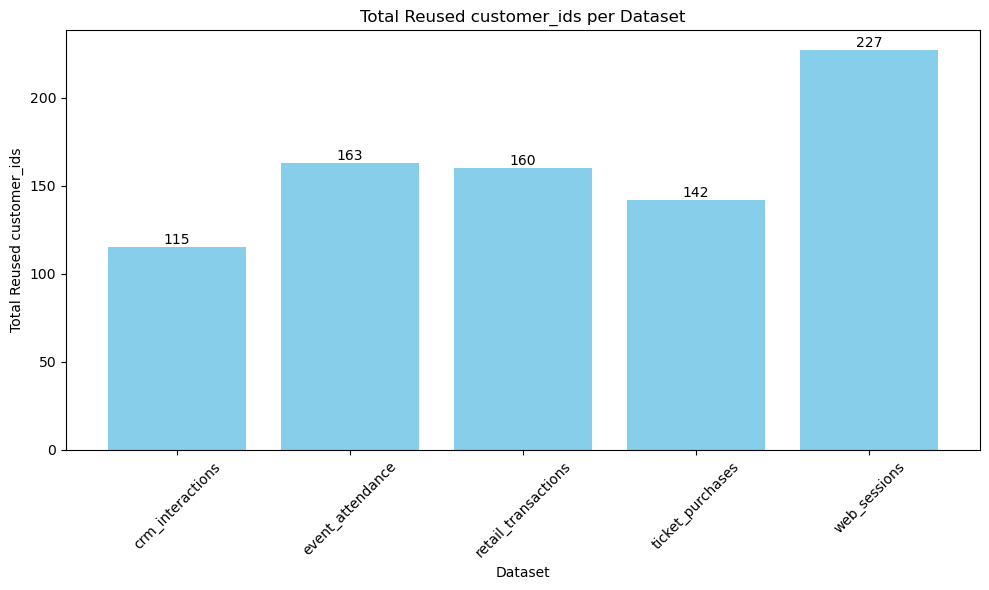

In [25]:
# Check how many `customer_id`s are re-used in more than one row per dataframe
reused_customer_ids = {}

for name, df in datasets.items():
  if name == 'customers':
    continue
  elif 'customer_id' not in df.columns:
    continue

  counts = df['customer_id'].value_counts()
  reused_customer_ids[name] = (counts > 1).sum()

# Plot the reused_customer_ids
plt.figure(figsize=(10, 6))
bars = plt.bar(
  reused_customer_ids.keys(),
  reused_customer_ids.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.xlabel('Dataset')
plt.ylabel('Total Reused customer_ids')
plt.title('Total Reused customer_ids per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/reused_customer_ids.png')
plt.show()

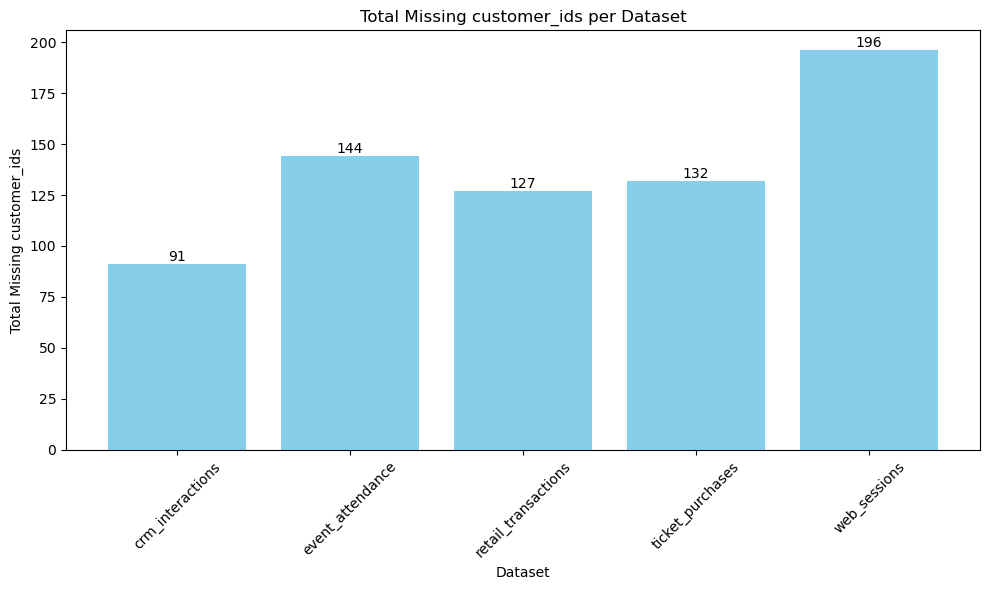

In [26]:
# Check how many `user_ids` are not present in `customers_df`
customer_ids = set(customers_df['customer_id'])
missing_customer_ids = {}

for name, df in datasets.items():
  if name == 'customers':
    continue
  elif 'customer_id' not in df.columns:
    continue

  df_customer_ids = set(df['customer_id'])
  missing_ids = df_customer_ids - customer_ids
  missing_ids_count = len(missing_ids)
  missing_customer_ids[name] = missing_ids_count

# Plot the missing_customer_ids
plt.figure(figsize=(10, 6))
bars = plt.bar(
  missing_customer_ids.keys(),
  missing_customer_ids.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.xlabel('Dataset')
plt.ylabel('Total Missing customer_ids')
plt.title('Total Missing customer_ids per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/missing_customer_ids.png')
plt.show()

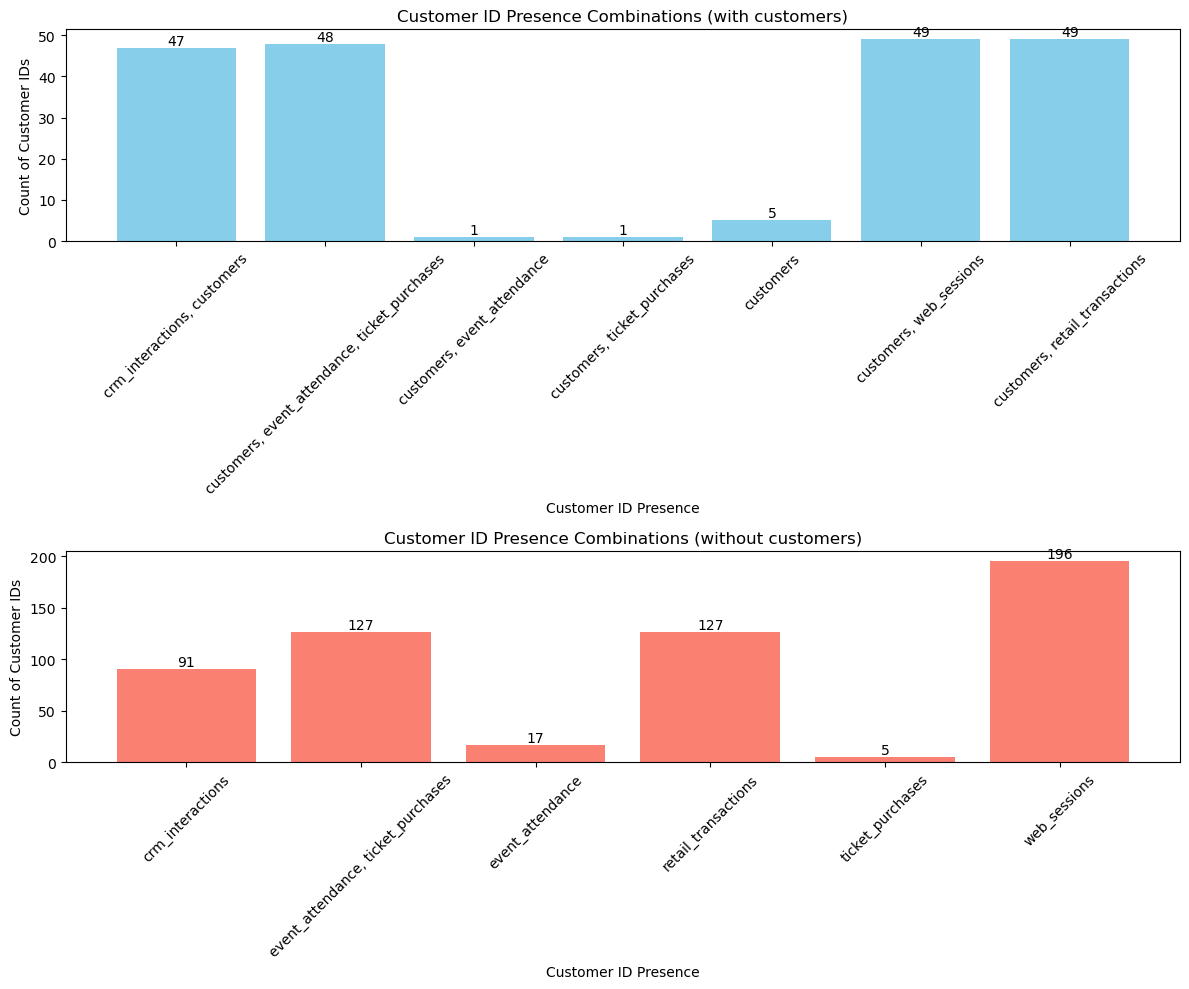

In [27]:
# For each customer_id, check what tables they appear in
customer_id_presence = {}
for name, df in datasets.items():
  # Ignore tables that do not have 'customer_id'
  if 'customer_id' not in df.columns:
    continue

  for customer_id in df['customer_id'].unique():
    # Track the presence of customer_id across tables
    if customer_id not in customer_id_presence:
      customer_id_presence[customer_id] = f"{name}"
    else:
      customer_id_presence[customer_id] += f", {name}"

# Count the number of `customer_id_presence` combinations
customer_id_combinations = {}
for value in customer_id_presence.values():
  customer_id_combinations[value] = customer_id_combinations.get(value, 0) + 1

# Make two plots:
# 1. Bar plot with customer combinations that contain 'customers'
# 2. Bar plot with customer combinations that do not contain 'customers'
combination_with_customers = {k: v for k, v in customer_id_combinations.items() if 'customers' in k}
combination_without_customers = {k: v for k, v in customer_id_combinations.items() if 'customers' not in k}

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot combination_with_customers
bars1 = axes[0].bar(
    combination_with_customers.keys(),
    combination_with_customers.values(),
    color='skyblue'
)
axes[0].bar_label(bars1)
axes[0].set_xlabel('Customer ID Presence')
axes[0].set_ylabel('Count of Customer IDs')
axes[0].set_title('Customer ID Presence Combinations (with customers)')
axes[0].tick_params(axis='x', rotation=45)

# Plot combination_without_customers
bars2 = axes[1].bar(
    combination_without_customers.keys(),
    combination_without_customers.values(),
    color='salmon'
)
axes[1].bar_label(bars2)
axes[1].set_xlabel('Customer ID Presence')
axes[1].set_ylabel('Count of Customer IDs')
axes[1].set_title('Customer ID Presence Combinations (without customers)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/customer_id_presence_combined.png')
plt.show()

#### Customer Linkage

Now, let's focus on the customer linkage table. Check if there are any unique customer IDs that are present in the `customer_linkage_df` that are not present in other tables. This will help us understand if there are any customers that are only represented in the linkage table and not in the main `customers_df`.

In [28]:
linkage_customer_ids = set()

# Check which values in customer linkage values
for column in customer_linkage_df.columns:
  # Ignore the `universal_id` column
  if column == 'universal_id':
    continue

  # Get the customer ID
  unique_values = customer_linkage_df[column].unique()
  # Add all of the customer IDs to linkage_customer_ids
  linkage_customer_ids.update(unique_values)

print(f"Number of unique `customer_ids` in `customer_linkage_df`: {len(linkage_customer_ids)}")

Number of unique `customer_ids` in `customer_linkage_df`: 382


In [29]:
# Calculate the amount of linkage customer IDs that are not present in any other table
missing_linkage_customer_ids = linkage_customer_ids.copy()
for name, df in datasets.items():
  # Ignore tables that do not have 'customer_id'
  if 'customer_id' not in df.columns:
    continue

  # Remove customer IDs that are available in other tables
  df_customer_ids = set(df['customer_id'])
  missing_linkage_customer_ids -= df_customer_ids

print(f"Number of unique `customer_ids` in `customer_linkage_df` and not in any other table: {len(missing_linkage_customer_ids)}")

Number of unique `customer_ids` in `customer_linkage_df` and not in any other table: 10


In [30]:
customer_ids = set(customers_df['customer_id'])
unmatched_linkage_customer_ids = linkage_customer_ids - customer_ids

print(f"Number of customer IDs in linkage data but not in customers data: {len(unmatched_linkage_customer_ids)}")

Number of customer IDs in linkage data but not in customers data: 282


In [31]:
# Get the number of customer_ids with multiple collisions in `customer_linkage_df`
valid_customer_ids = set(customers_df['customer_id'])
linkage_id_columns = [col for col in customer_linkage_df.columns if col != 'universal_id']
collisions = 0

for row in customer_linkage_df[linkage_id_columns].itertuples(index=False):
  row_ids = {val for val in row if pd.notnull(val)}

  # Check for customer_id intersections that appear more than once
  matched_ids = row_ids.intersection(valid_customer_ids)  
  if len(matched_ids) > 1:
      collisions += 1

print(f"Total rows with multiple `customer_id` collisions: {collisions}")

Total rows with multiple `customer_id` collisions: 24


#### Event Attendance

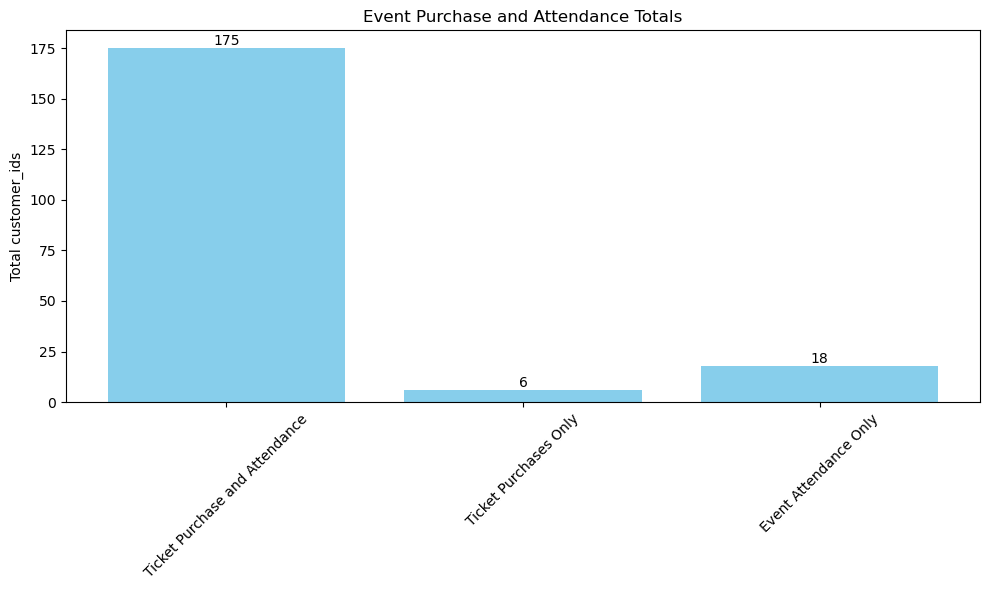

In [32]:
# Calculate the counts
ticket_purchases_customer_ids = set(ticket_purchases_df['customer_id'])
event_attendance_customer_ids = set(event_attendance_df['customer_id'])

both_purchase_and_attendance = ticket_purchases_customer_ids & event_attendance_customer_ids
ticket_purchases_not_in_attendance = ticket_purchases_customer_ids - event_attendance_customer_ids
event_attendance_not_in_ticket_purchases = event_attendance_customer_ids - ticket_purchases_customer_ids

# Structure data for plotting
plot_data = {
    'Ticket Purchase and Attendance': len(both_purchase_and_attendance),
    'Ticket Purchases Only': len(ticket_purchases_not_in_attendance),
    'Event Attendance Only': len(event_attendance_not_in_ticket_purchases)
}

# Plot the event ticket purchase and attendance counts
plt.figure(figsize=(10, 6))
bars = plt.bar(
  plot_data.keys(),
  plot_data.values(),
  color='skyblue'
)

plt.bar_label(bars)
plt.ylabel('Total customer_ids')
plt.title('Event Purchase and Attendance Totals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/event_purchase_and_attendance_totals.png')
plt.show()

- Somebody can buy tickets without attending events. Currently, there are 6 customer_ids in `ticket_purchases_df` that are not in `event_attendance_df`. This could be due to various reasons such as cancellations, no-shows, or gifting the ticket to another customer
- Somebody can attend an event without buying a ticket. Currently, there are 4 customer_ids in `event_attendance_df` that are not in `ticket_purchases_df`. This could be due to various reasons such as receiving a complimentary ticket or attending an event without purchasing a ticket.